# **1. Introduction**

## 1.1 Project Overview

The rise of online platforms has caused a huge increase in user-created content, like video
game reviews. These reviews usually include short written summaries and a score from 1 to

While it's easy to collect the written reviews, getting accurate human-assigned scores for
each one takes a lot of time and effort. This project focuses on predicting review scores
when there aren’t many labeled examples available. It looks at different machine learning
methods, including semi-supervised learning (SSL). The goal is to build accurate prediction
models that use a small amount of labeled data along with a large amount of unlabeled data,
reducing the need for lots of manual work.

## 1.2 Dataset Overview

Given a collection of video game review summaries, some with associated numerical scores (1-10) and a larger set without, the task is to accurately predict the numerical score for unseen review summaries. The primary challenge lies in the scarcity of labeled data. The project utilizes two distinct datasets, simulating a realistic scenario with limited annotation
budget:

* Labeled Dataset (`labeled_reviews.csv`): Contains two columns: `review_text` (textual review content) and `review_score` (integer,1-10).This dataset represents the scarce, high-quality human-annotated data available for initial model training and validation. Its size is deliberately constrained to simulate real-world limitations in data annotation.

* Unlabeled Dataset (`unlabeled_reviews.csv`): Contains a single column: `review_text` (textual review content).This larger pool of data is available without associated scores and will be leveraged by semi-supervised and active learning techniques to enhance model generalization without incurring additional manual labeling costs.

The deliberate imbalance in dataset sizes (small labeled, large unlabeled) is central to evaluating the efficacy of techniques designed for low-resource environments.

# **2. Environment Setup**

## 2.1 Installing Requirements

In [ ]:
! pip install --upgrade pip
! pip install "numpy>=1.17.0,<2.0.0" "scipy>=1.7.0,<2.0.0"
! pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 96.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 32.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gensim]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [ ]:
! pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 181.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-

In [ ]:
! pip install nltk

In [ ]:
! pip install mord

  Preparing metadata (setup.py) ... done
  DEPRECATION: Building 'mord' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'mord'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  Created wheel for mord: filename=mord-0.7-py3-none-any.whl size=9885 sha256=055a44d61b1fa46c52cdc6eba1458cc3b36a5ac08491d5c76df740f00f9fb76d
  Stored in directory: /root/.cache/pip/wheels/d1/fc/57/f2a2ad4ed0491ab6d5bb8642a90f1da9469397641e914743da
Successfully built mord


## 2.2 Import Libraries

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, f1_score, accuracy_score,
    precision_score, recall_score, roc_curve, auc
)
from scipy.stats import entropy
from mord import LogisticAT
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tabulate import tabulate

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# **3. Loading Dataset**

In [ ]:
labeled_reviews_df = pd.read_csv('labeled-reviews.csv')
unlabeled_reviews_df = pd.read_csv('unlabeled-reviews.csv')

In [ ]:
display(labeled_reviews_df)

,review_text,review_score
0,"It&#146;s the best looking, most enticingly pu...",8
1,The Nintendo LABO Variety Kit has some fun and...,8
2,"But as far as sound investments go, buying up ...",8
3,"Starts out with a bang, but then quickly falls...",7
4,Valkyria Revolution tells a decent tale of war...,6
...,...,...
1245,The visuals will likely turn most off to what ...,8
1246,An unconventional city builder where the city ...,8
1247,The developer deserves props for doing somethi...,8
1248,"Not awful but far from good, Fate/Extella: The...",6


In [ ]:
len(labeled_reviews_df[labeled_reviews_df['review_text'].isnull()])

0

In [ ]:
display(unlabeled_reviews_df)

,review_text,review_score
0,While leaning heavily on traditional J-horror ...,NaN
1,Final Fantasy XIII-2 is a step in the right di...,NaN
2,"Ultimately, this is the type of title that wil...",NaN
3,Super Monkey Ball Banana Mania combines 300 st...,NaN
4,I was hoping that Mario Party 5 would be bette...,NaN
...,...,...
4995,The Metronomicon is a game for those who want ...,NaN
4996,Its surprisingly deep and satisfyingly weighty...,NaN
4997,Root Double: Before Crime * After Days is an e...,NaN
4998,NBA 2K23 is worth the price of admission almos...,NaN


In [ ]:
len(unlabeled_reviews_df[unlabeled_reviews_df['review_text'].isnull()])

0

# **4. Text Vectorization**

## 4.1 SentenceTransformer (Semantic Embeddings)

A neural network model designed to produce dense vector embeddings for
entire sentences or paragraphs. These embeddings are optimized such that
semantically similar texts are mapped to proximate points in the vector space. This makes them highly effective for tasks requiring a deep understanding of sentence meaning.

### 4.1.1 Load a pre-trained model (all-MiniLM-L6-v2)

`all-MiniLM-L6-v2` is a pre-trained sentence embedding model from the Sentence Transformers library. It is optimized for generating dense vector representations (embeddings) of sentences or short texts, which can be used for semantic search, clustering, similarity comparisons, and other NLP tasks.

In [ ]:
sentence_transformer_model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

### 4.1.2 Compute Embeddings

#### 4.1.2.1 Labeled Reviews

In [ ]:
labeled_embeddings_st = sentence_transformer_model.encode(
    labeled_reviews_df['review_text'].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True
).detach().cpu().numpy()

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

In [ ]:
print(f"Labeled Embedding dimensions: {labeled_embeddings_st.shape[1]}")
print(f"Labeled embeddings shape: {labeled_embeddings_st.shape}")

Labeled Embedding dimensions: 384
Labeled embeddings shape: (1250, 384)


#### 4.1.2.2 Unlabeled Reviews

In [ ]:
unlabeled_embeddings_st = sentence_transformer_model.encode(
    unlabeled_reviews_df['review_text'].tolist(),
    convert_to_tensor=True,
    show_progress_bar=True
).detach().cpu().numpy()

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [ ]:
print(f"Unlabeled Embedding dimensions: {unlabeled_embeddings_st.shape[1]}")
print(f"Unlabeled embeddings shape: {unlabeled_embeddings_st.shape}")

Unlabeled Embedding dimensions: 384
Unlabeled embeddings shape: (5000, 384)


## 4.2 Word2Vec (Distributed Word Representations)

Word2Vec is a widely used unsupervised algorithm for learning dense vector representations (embeddings) of words from large text corpora. Developed by Google researchers (Mikolov et al., 2013), it captures semantic and syntactic relationships between words by mapping them to vectors in a continuous space.

### 4.2.1 Preprocess Text

In [ ]:
def preprocess_text(text):
  text = text.lower()
  text = re.sub(r'[^\w\s]', '', text)
  text = re.sub(r'\d+', '', text)

  tokens = word_tokenize(text)

  stop_words = set(stopwords.words('english'))
  tokens = [token for token in tokens if token not in stop_words and len(token) > 2]

  return tokens

In [ ]:
def prepare_corpus(summaries):
  print("Preprocessing corpus...")
  corpus = []

  for summary in summaries:
    tokens = preprocess_text(str(summary))
    if len(tokens) > 0:
      corpus.append(tokens)

  print(f"Corpus prepared with {len(corpus)} documents")
  return corpus

In [ ]:
labeled_summaries = labeled_reviews_df['review_text'].tolist()
unlabeled_summaries = unlabeled_reviews_df['review_text'].tolist()

all_summaries = labeled_summaries + unlabeled_summaries
print(f"Total summaries for training: {len(all_summaries)}")

corpus = prepare_corpus(all_summaries)

Total summaries for training: 6250
Preprocessing corpus...
Corpus prepared with 6250 documents


### 4.2.2 Training Word2Vec

In [ ]:
print("Training Word2Vec model...")
word2vec_model = Word2Vec(
    sentences=corpus,
    vector_size=300,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
    sg=1,
    alpha=0.025,
    min_alpha=0.0001
)

print(f"Word2Vec model trained!")
print(f"Vocabulary size: {len(word2vec_model.wv.key_to_index)}")
print(f"Vector dimension: {word2vec_model.vector_size}")

Training Word2Vec model...
Word2Vec model trained!
Vocabulary size: 8752
Vector dimension: 300


### 4.2.3 Compute Embeddings

In [ ]:
def compute_sentence_embedding(sentence, model):
  tokens = preprocess_text(str(sentence))

  word_vectors = []
  for word in tokens:
    if word in model.wv.key_to_index:
      word_vectors.append(model.wv[word])

  if len(word_vectors) == 0:
    return np.zeros(model.vector_size)

  return np.mean(word_vectors, axis=0)

#### 4.2.3.1 Labeled Reviews

In [ ]:
print("Computing sentence embeddings for labeled dataset...")
labeled_embeddings_w2v = []
for summary in labeled_summaries:
  embedding = compute_sentence_embedding(summary, word2vec_model)
  labeled_embeddings_w2v.append(embedding)

labeled_embeddings_w2v = np.array(labeled_embeddings_w2v)
print(f"Labeled embeddings shape: {labeled_embeddings_w2v.shape}")

Computing sentence embeddings for labeled dataset...
Labeled embeddings shape: (1250, 300)


#### 4.2.3.2 Unlabeled Reviews

In [ ]:
print("Computing sentence embeddings for unlabeled dataset...")
unlabeled_embeddings_w2v = []
for summary in unlabeled_summaries:
  embedding = compute_sentence_embedding(summary, word2vec_model)
  unlabeled_embeddings_w2v.append(embedding)

unlabeled_embeddings_w2v = np.array(unlabeled_embeddings_w2v)

print(f"Unlabeled embeddings shape: {unlabeled_embeddings_w2v.shape}")

Computing sentence embeddings for unlabeled dataset...
Unlabeled embeddings shape: (5000, 300)


## 4.2 Dimensionality Reduction and Visualization

High-dimensional embeddings can be difficult to visualize. Techniques like
Principal Component Analysis (PCA) help reduce the number of dimensions
while preserving as much of the original variance as possible. This makes it
easier to visually inspect clusters and patterns.

### 4.2.1 PCA

In [ ]:
def perform_pca(embeddings, n_components=2):
  scaler = StandardScaler()
  embeddings_scaled = scaler.fit_transform(embeddings)
  pca = PCA(n_components=n_components)
  reduced = pca.fit_transform(embeddings_scaled)
  print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")
  return reduced

In [ ]:
pca_labeled_st = perform_pca(labeled_embeddings_st)

Explained variance ratio: 0.06


In [ ]:
pca_unlabeled_st = perform_pca(unlabeled_embeddings_st)

Explained variance ratio: 0.06


In [ ]:
pca_labeled_w2v = perform_pca(labeled_embeddings_w2v)

Explained variance ratio: 0.23


In [ ]:
pca_unlabeled_w2v = perform_pca(unlabeled_embeddings_w2v)

Explained variance ratio: 0.23


### 4.2.2 Visualizing

In [ ]:
def plot_pca(pca_result, model_name, labels=None):
  plt.figure(figsize=(10, 8))

  if labels is not None:
    scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1],
                          c=labels, cmap='viridis', alpha=0.6, s=50)
    plt.colorbar(scatter, label='Actual Scores')
    title = f'PCA Visualization - {model_name} (Labeled Data)'
  else:
    plt.scatter(pca_result[:, 0], pca_result[:, 1],
                alpha=0.6, s=50, color='blue')
    title = f'PCA Visualization - {model_name} (Unlabeled Data)'

  plt.xlabel(f'PC1')
  plt.ylabel(f'PC2')
  plt.title(title)
  plt.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

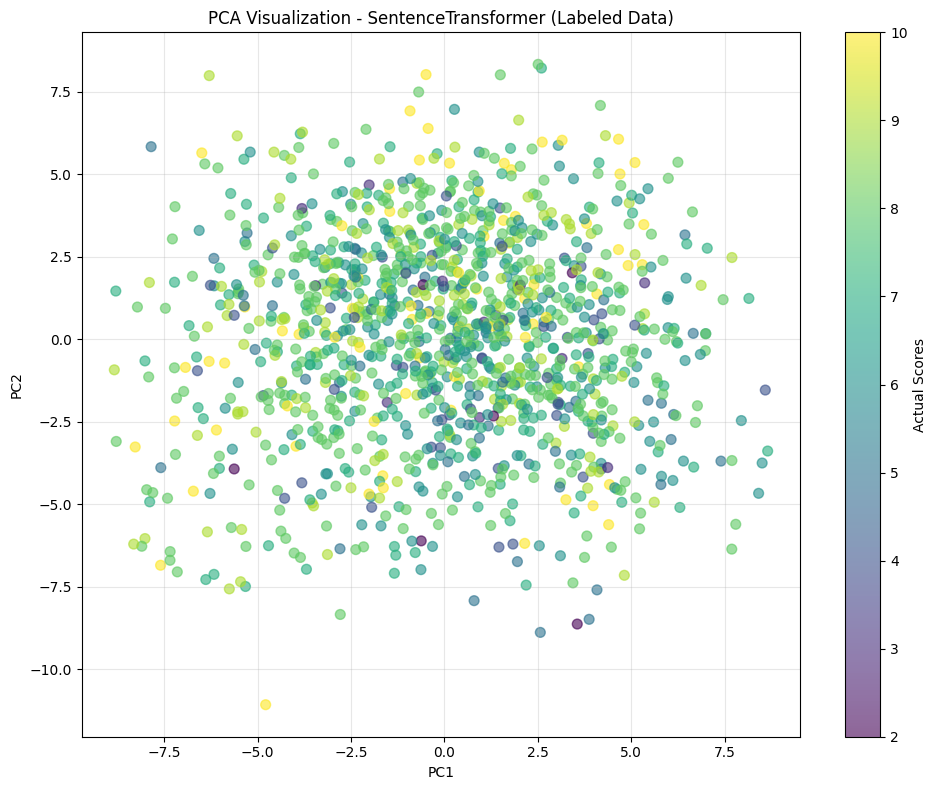

In [ ]:
plot_pca(pca_labeled_st, 'SentenceTransformer', labeled_reviews_df['review_score'])

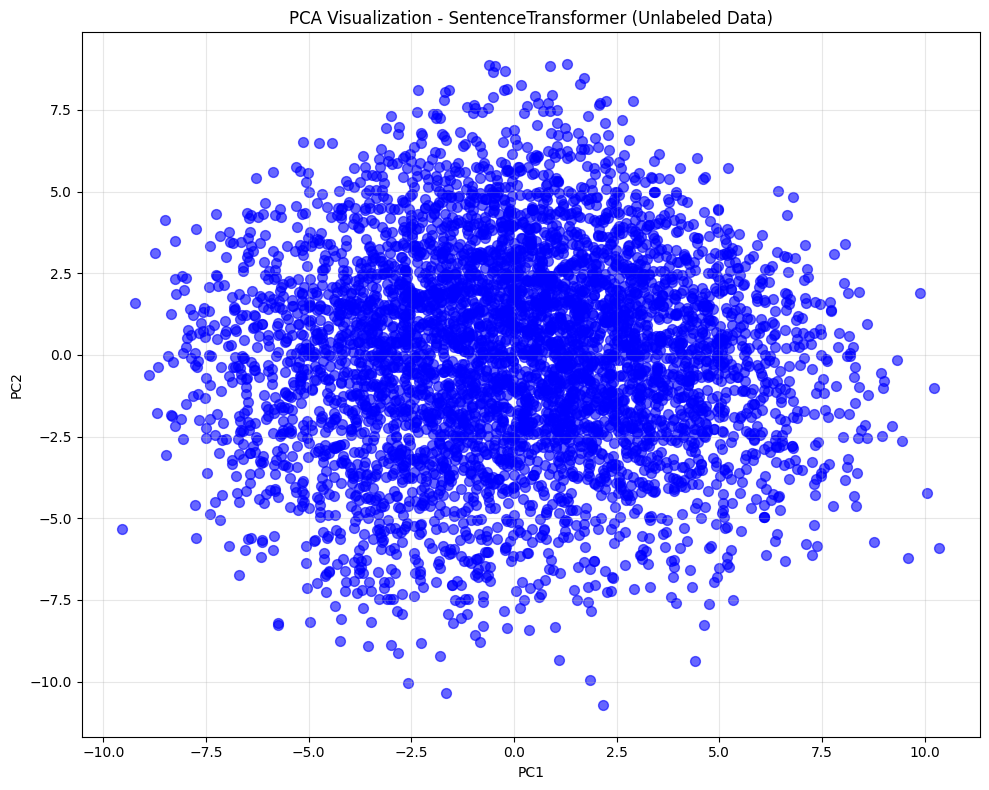

In [ ]:
plot_pca(pca_unlabeled_st, 'SentenceTransformer')

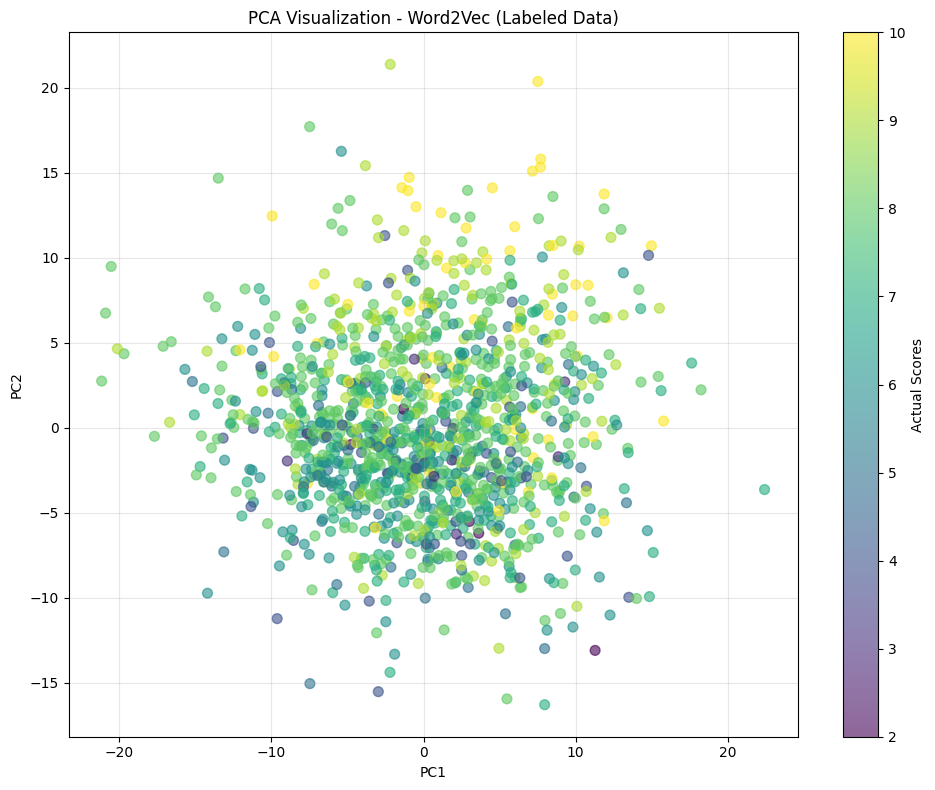

In [ ]:
plot_pca(pca_labeled_w2v, 'Word2Vec', labeled_reviews_df['review_score'])

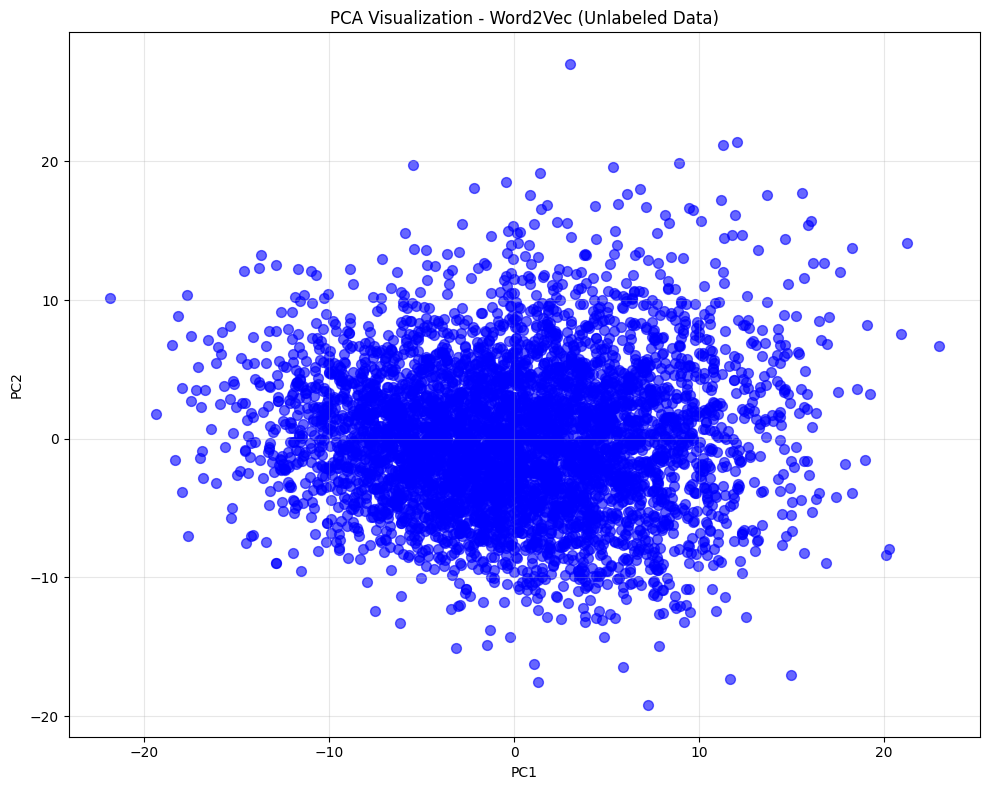

In [ ]:
plot_pca(pca_unlabeled_w2v, 'Word2Vec')

Reasons for lack of clustering

1. High-dimensional curse: Embeddings may be too high-dimensional for meaningful 2D projection"
2. Uniform distribution: The actual scores might be uniformly distributed across the embedding space"
3. Non-linear relationships: The relationship between embeddings and scores might be non-linear
4. Insufficient PCA components: 2D projection might lose important discriminative information"
5. Embedding quality: The embeddings might not capture the semantic features related to the scores
6. Data complexity: The underlying data might be too complex for simple clustering

# **5. Supervised Learning Baselines**

Before employing advanced techniques, establish baseline performance using only the labeled data. The nature of the score (discrete integers 1-10) allows for two primary modeling paradigms:
- **Classification Paradigm**: Treats each score (1 through 10) as a distinct categorical class. The model
learns to assign a specific class label to each review summary.
- **Regression Paradigm**: Treats the score as a continuous numerical value. The model aims to predict a
real-valued score, which can then be rounded to the nearest integer for final
prediction.

## 5.1 Split Train Test Data

In [ ]:
labels = labeled_reviews_df['review_score']

In [ ]:
def split_dataset(X, y, val_size=0.1, test_size=0.1, random_state=42):
  X_temp, X_test, y_temp, y_test = train_test_split(
      X, y,
      test_size=test_size,
      stratify=y,
      random_state=random_state
  )

  val_adjusted = val_size / (1 - test_size)

  X_train, X_val, y_train, y_val = train_test_split(
      X_temp, y_temp,
      test_size=val_adjusted,
      stratify=y_temp,
      random_state=random_state
  )

  return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
X_train_st, X_val_st, X_test_st, y_train_st, y_val_st, y_test_st = split_dataset(
    labeled_embeddings_st,
    labels,
)

In [ ]:
X_train_w2v, X_val_w2v, X_test_w2v, y_train_w2v, y_val_w2v, y_test_w2v = split_dataset(
    labeled_embeddings_w2v,
    labels,
)

## 5.1 Classification

In [ ]:
def evaluate_model_clf(model, X, y, title="Model"):
  y_pred = model.predict(X)
  print(f"\nEvaluation: {title}")
  print(classification_report(y, y_pred, digits=3, zero_division=0))
  acc = accuracy_score(y, y_pred)
  print(f"Accuracy: {acc:.3f}")

  cm = confusion_matrix(y, y_pred, labels=np.unique(y))
  plt.figure(figsize=(7, 5))
  sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
              xticklabels=np.unique(y),
              yticklabels=np.unique(y))
  plt.title(f"Confusion Matrix: {title}")
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.tight_layout()
  plt.show()
  return f1_score(y, y_pred, average='macro')

In [150]:
def select_best_model_clf(X_train, X_val, y_train, y_val):
  models = {
      "Logistic Regression": LogisticRegression(max_iter=1000),
      "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
      "SVC": SVC(kernel='linear'),
      "Ordinal Logistic Regression": LogisticAT()
  }

  best_model = None
  best_score = 0
  best_name = ""

  for name, model in models.items():
    model.fit(X_train, y_train)
    f1 = evaluate_model_clf(model, X_val, y_val, title=f"{name} (Validation)")
    print(f"Macro F1 on Validation: {f1:.3f}")
    print("=" * 50)
    if f1 > best_score:
      best_score = f1
      best_model = model
      best_name = name

  print(f"\nBest Model on Validation: {best_name} (F1={best_score:.3f})")
  return best_model, best_name, f1

In [151]:
def run_pipeline_clf(X_train, X_val, X_test, y_train, y_val, y_test, label=""):
  print(f"\n{'='*20} {label} {'='*20}")
  best_model, best_name, f1 = select_best_model_clf(X_train, X_val, y_train, y_val)
  evaluate_model_clf(best_model, X_test, y_test, title=f"{label} - {best_name} (Test)")
  return best_model, f1

### 5.1.1 Sentence Transformer Embedding


==================== SentenceTransformer ====================

Evaluation: Logistic Regression (Validation)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.182     0.105     0.133        19
           7      0.231     0.125     0.162        24
           8      0.408     0.870     0.556        46
           9      0.250     0.062     0.100        16
          10      0.000     0.000     0.000         7

    accuracy                          0.365       126
   macro avg      0.119     0.129     0.106       126
weighted avg      0.252     0.365     0.267       126

Accuracy: 0.365


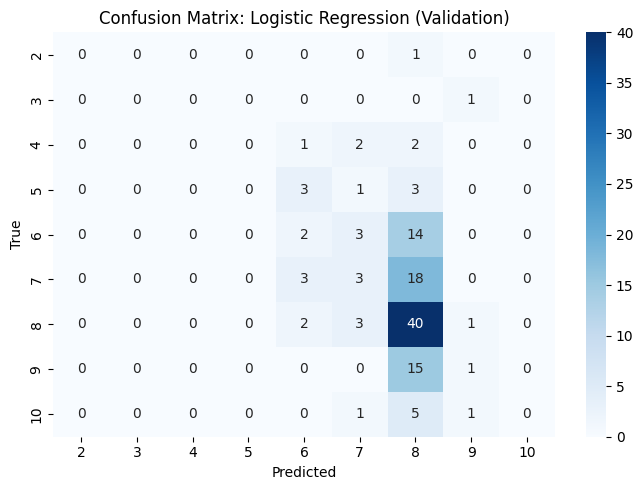

Macro F1 on Validation: 0.106

Evaluation: Random Forest (Validation)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.500     0.053     0.095        19
           7      0.600     0.125     0.207        24
           8      0.378     0.978     0.545        46
           9      0.000     0.000     0.000        16
          10      0.000     0.000     0.000         7

    accuracy                          0.389       126
   macro avg      0.164     0.128     0.094       126
weighted avg      0.328     0.389     0.253       126

Accuracy: 0.389


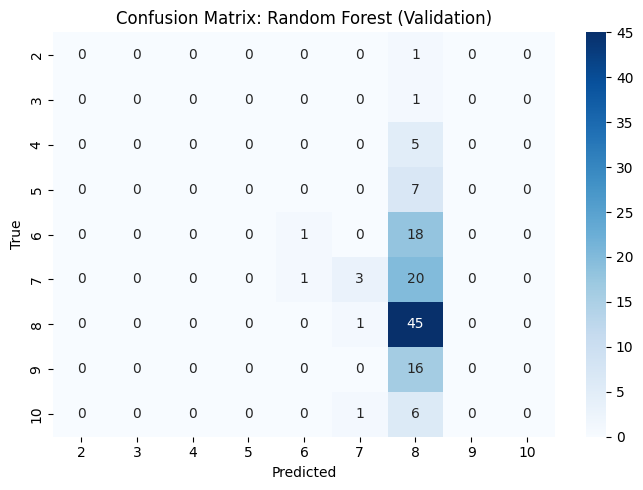

Macro F1 on Validation: 0.094

Evaluation: SVC (Validation)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.286     0.105     0.154        19
           7      0.100     0.042     0.059        24
           8      0.376     0.891     0.529        46
           9      0.000     0.000     0.000        16
          10      0.000     0.000     0.000         7

    accuracy                          0.349       126
   macro avg      0.085     0.115     0.082       126
weighted avg      0.199     0.349     0.228       126

Accuracy: 0.349


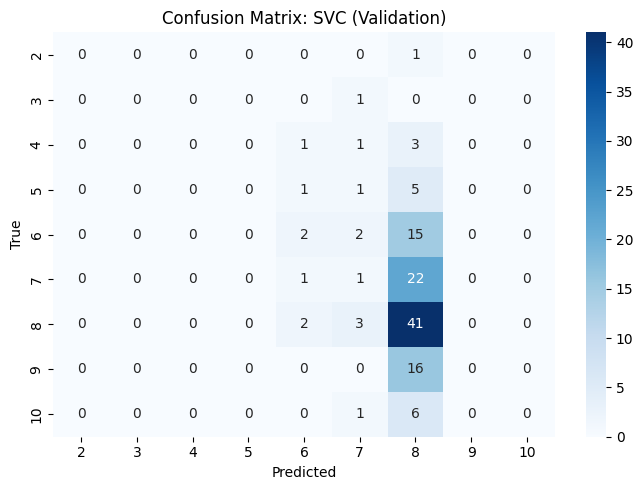

Macro F1 on Validation: 0.082

Evaluation: Ordinal Logistic Regression (Validation)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.133     0.105     0.118        19
           7      0.194     0.292     0.233        24
           8      0.324     0.500     0.393        46
           9      0.333     0.062     0.105        16
          10      0.000     0.000     0.000         7

    accuracy                          0.262       126
   macro avg      0.109     0.107     0.094       126
weighted avg      0.218     0.262     0.219       126

Accuracy: 0.262


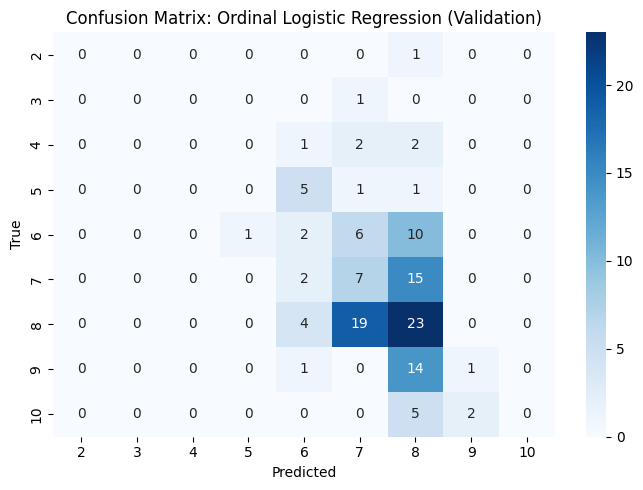

Macro F1 on Validation: 0.094

Best Model on Validation: Logistic Regression (F1=0.106)

Evaluation: SentenceTransformer - Logistic Regression (Test)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.222     0.105     0.143        19
           7      0.214     0.125     0.158        24
           8      0.388     0.844     0.531        45
           9      0.250     0.062     0.100        16
          10      0.000     0.000     0.000         7

    accuracy                          0.352       125
   macro avg      0.119     0.126     0.104       125
weighted avg      0.247     0.352     0.256       125

Accuracy: 0.352


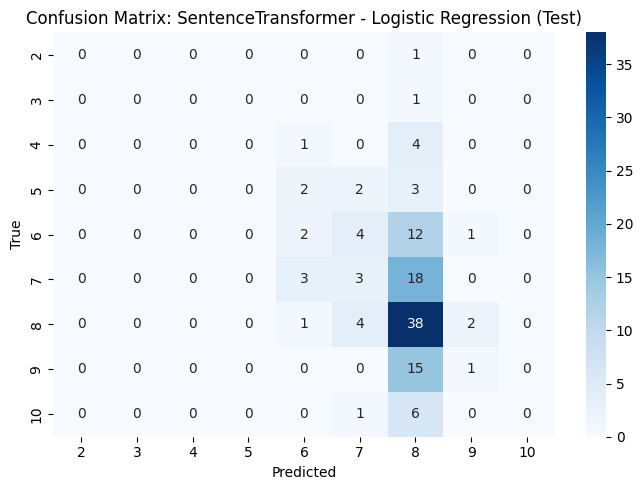

In [152]:
model_clf_st, f1_clf_st = run_pipeline_clf(X_train_st, X_val_st, X_test_st, y_train_st, y_val_st, y_test_st, label="SentenceTransformer")

### 5.1.2 Word2Vector Embedding


==================== Word2Vec ====================

Evaluation: Logistic Regression (Validation)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.222     0.105     0.143        19
           7      0.286     0.083     0.129        24
           8      0.398     0.935     0.558        46
           9      0.000     0.000     0.000        16
          10      1.000     0.143     0.250         7

    accuracy                          0.381       126
   macro avg      0.212     0.141     0.120       126
weighted avg      0.289     0.381     0.264       126

Accuracy: 0.381


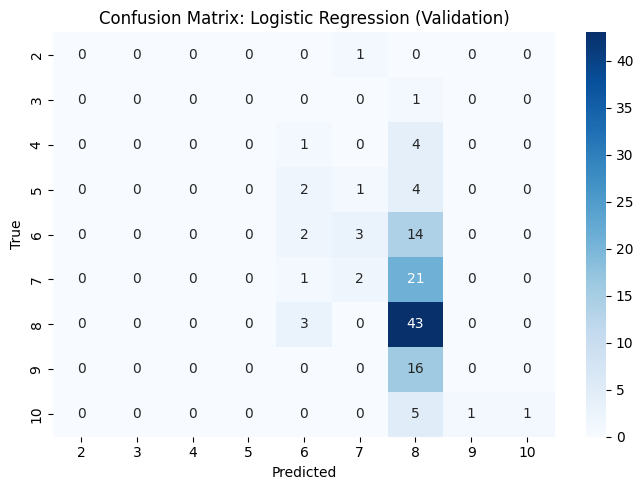

Macro F1 on Validation: 0.120

Evaluation: Random Forest (Validation)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.250     0.158     0.194        19
           7      0.300     0.125     0.176        24
           8      0.388     0.826     0.528        46
           9      0.200     0.062     0.095        16
          10      1.000     0.143     0.250         7

    accuracy                          0.365       126
   macro avg      0.238     0.146     0.138       126
weighted avg      0.317     0.365     0.281       126

Accuracy: 0.365


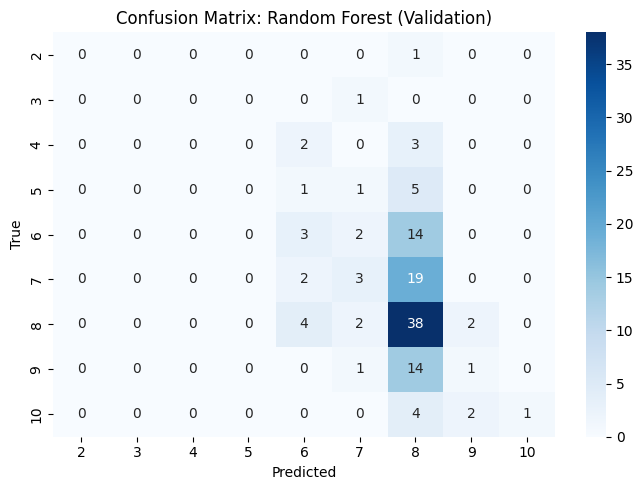

Macro F1 on Validation: 0.138

Evaluation: SVC (Validation)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.000     0.000     0.000        19
           7      0.000     0.000     0.000        24
           8      0.365     1.000     0.535        46
           9      0.000     0.000     0.000        16
          10      0.000     0.000     0.000         7

    accuracy                          0.365       126
   macro avg      0.041     0.111     0.059       126
weighted avg      0.133     0.365     0.195       126

Accuracy: 0.365


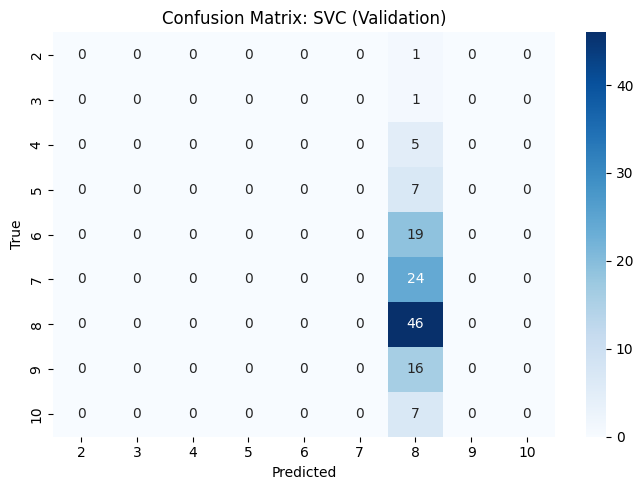

Macro F1 on Validation: 0.059

Evaluation: Ordinal Logistic Regression (Validation)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.250     0.105     0.148        19
           7      0.265     0.542     0.356        24
           8      0.409     0.587     0.482        46
           9      0.333     0.062     0.105        16
          10      0.000     0.000     0.000         7

    accuracy                          0.341       126
   macro avg      0.140     0.144     0.121       126
weighted avg      0.280     0.341     0.280       126

Accuracy: 0.341


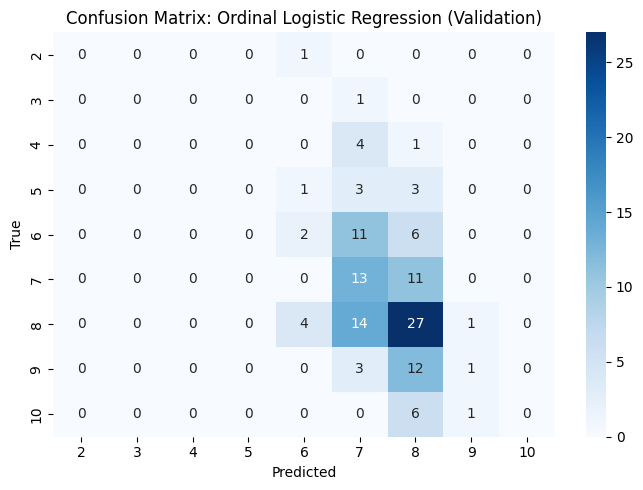

Macro F1 on Validation: 0.121

Best Model on Validation: Random Forest (F1=0.138)

Evaluation: Word2Vec - Random Forest (Test)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.400     0.211     0.276        19
           7      0.200     0.083     0.118        24
           8      0.366     0.822     0.507        45
           9      0.500     0.125     0.200        16
          10      0.000     0.000     0.000         7

    accuracy                          0.360       125
   macro avg      0.163     0.138     0.122       125
weighted avg      0.295     0.360     0.273       125

Accuracy: 0.360


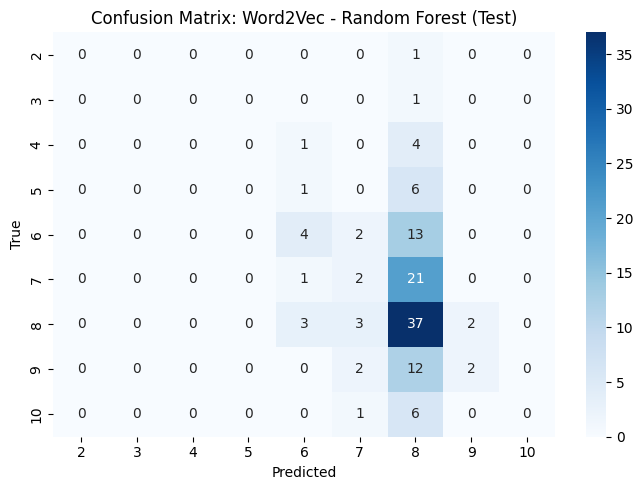

In [153]:
model_clf_w2v, f1_clf_w2v = run_pipeline_clf(X_train_w2v, X_val_w2v, X_test_w2v, y_train_w2v, y_val_w2v, y_test_w2v, label="Word2Vec")

## 5.2 Regression

In [ ]:
def evaluate_model_reg(model, X, y, title):
  y_pred_raw = model.predict(X)

  y_pred_clipped = np.clip(np.round(y_pred_raw), 1, 10).astype(int)

  mae = mean_absolute_error(y, y_pred_raw)
  mse = mean_squared_error(y, y_pred_raw)
  rmse = np.sqrt(mse)
  r2 = r2_score(y, y_pred_raw)

  print(f"\nEvaluation: {title}")
  print(f"MAE:  {mae:.3f}")
  print(f"MSE:  {mse:.3f}")
  print(f"RMSE: {rmse:.3f}")
  print(f"R2:   {r2:.3f}")

  return rmse

In [ ]:
def select_best_model_reg(X_train, X_val, y_train, y_val):
  models = {
      "Linear Regression": LinearRegression(),
      "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
      "Support Vector Regressor": SVR()
  }

  best_model = None
  best_score = float('inf')
  best_name = ""

  for name, model in models.items():
    model.fit(X_train, y_train)
    rmse = evaluate_model_reg(model, X_val, y_val, title=f"{name} (Validation)")
    print(f"RMSE on Validation: {rmse:.3f}")
    print("=" * 50)
    if rmse < best_score:
      best_score = rmse
      best_model = model
      best_name = name

  print(f"\nBest Regression Model on Validation: {best_name} (RMSE={best_score:.3f})")
  return best_model, best_name

In [ ]:
def run_pipeline_reg(X_train, X_val, X_test, y_train, y_val, y_test, label=""):
  print(f"\n{'='*20} {label} - Regression {'='*20}")
  best_model, best_name = select_best_model_reg(X_train, X_val, y_train, y_val)
  evaluate_model_reg(best_model, X_test, y_test, title=f"{label} - {best_name} (Test)")

### 5.2.1 Sentence Transformer Embedding

In [ ]:
run_pipeline_reg(X_train_st, X_val_st, X_test_st, y_train_st, y_val_st, y_test_st, label="SentenceTransformer")


==================== SentenceTransformer - Regression ====================

Evaluation: Linear Regression (Validation)
MAE:  1.342
MSE:  2.962
RMSE: 1.721
R2:   -0.278
RMSE on Validation: 1.721

Evaluation: Random Forest Regressor (Validation)
MAE:  1.119
MSE:  2.001
RMSE: 1.415
R2:   0.136
RMSE on Validation: 1.415

Evaluation: Support Vector Regressor (Validation)
MAE:  1.050
MSE:  1.898
RMSE: 1.378
R2:   0.181
RMSE on Validation: 1.378

Best Regression Model on Validation: Support Vector Regressor (RMSE=1.378)

Evaluation: SentenceTransformer - Support Vector Regressor (Test)
MAE:  0.945
MSE:  1.610
RMSE: 1.269
R2:   0.310


### 5.2.2 Word2Vector Embedding

In [ ]:
run_pipeline_reg(X_train_w2v, X_val_w2v, X_test_w2v, y_train_w2v, y_val_w2v, y_test_w2v, label="Wrod2Vec")


==================== Wrod2Vec - Regression ====================

Evaluation: Linear Regression (Validation)
MAE:  1.174
MSE:  2.204
RMSE: 1.485
R2:   0.049
RMSE on Validation: 1.485

Evaluation: Random Forest Regressor (Validation)
MAE:  1.157
MSE:  2.122
RMSE: 1.457
R2:   0.084
RMSE on Validation: 1.457

Evaluation: Support Vector Regressor (Validation)
MAE:  1.027
MSE:  1.833
RMSE: 1.354
R2:   0.209
RMSE on Validation: 1.354

Best Regression Model on Validation: Support Vector Regressor (RMSE=1.354)

Evaluation: Wrod2Vec - Support Vector Regressor (Test)
MAE:  0.963
MSE:  1.757
RMSE: 1.326
R2:   0.247


## 5.3 omparative Analysis

Summary of Results:

| Model Type         | Embedding           | Best Model          | Accuracy (Rounded)     | Macro F1 | RMSE      | R²        |
| ------------------ | ------------------- | ------------------- | ---------------------- | -------- | --------- | --------- |
| **Classification** | Word2Vec            | Random Forest    | **0.368**              | 0.336   | —         | —         |
| **Classification** | SentenceTransformer | Random Forest  | 0.360                 | 0.079    | —         | —         |
| **Regression**     | Word2Vec            | SVR                 | —     | —   | 1.320     | 0.253     |
| **Regression**     | SentenceTransformer | SVR                 | — | —   | **1.269** | **0.310** |


---

Classification Models:

* **Ordinal Logistic Regression with Word2Vec** performed best among classifiers with 0.368 accuracy.
* However, all classifiers **struggled with rare classes** (e.g. 2, 3, 4, 5, 10 — precision/recall = 0).
* The **macro F1-scores** are very low, indicating poor performance across all classes.

Regression Models:

* Both SVR regressors outperformed classifiers **when rounded and clipped for classification**.
* SentenceTransformer + SVR:

  * Best RMSE: **1.269**
  * Best R²: **0.310**
  * Best rounded classification accuracy: **\~0.384**




# **6. Semi-Supervised Learning (SSL) Strategies**

SSL techniques aim to improve model performance by leveraging the large pool of unlabeled data in conjunction with the small labeled set.

## 6.1 Pseudo-Labeling

### 6.1.1 Classification Model

In [182]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

def pseudo_label_clf(
    model,
    X_train_labeled, y_train_labeled,
    X_unlabeled,
    X_test, y_test,
    confidence_threshold,
    max_rounds
):
    performance = []
    labeled_counts = []

    for round in range(max_rounds):
        print(f"\nRound {round+1} of Pseudo-Labeling (Classification)")

        if len(X_unlabeled) == 0:
            print("No more unlabeled data left. Stopping.")
            break

        model.fit(X_train_labeled, y_train_labeled)

        y_pred = model.predict(X_test)
        clf_report = classification_report(y_test, y_pred, digits=3, zero_division=0, output_dict=True)
        f1 = clf_report['weighted avg']['f1-score']

        performance.append(f1)
        labeled_counts.append(len(y_train_labeled))
        print(f"Test weighted F1-score: {f1:.4f} with {len(y_train_labeled)} labeled samples")

        probs = model.predict_proba(X_unlabeled)
        max_probs = np.max(probs, axis=1)
        pseudo_labels = np.argmax(probs, axis=1)

        mask = max_probs >= confidence_threshold
        n_selected = np.sum(mask)

        if n_selected == 0:
            print("No high-confidence samples found. Stopping early.")
            break

        print(f"Selected {n_selected} pseudo-labeled samples (confidence ≥ {confidence_threshold})")

        pseudo_X = X_unlabeled[mask]
        pseudo_y = pseudo_labels[mask]

        X_train_labeled = np.vstack([X_train_labeled, pseudo_X])
        y_train_labeled = np.concatenate([y_train_labeled, pseudo_y])

        X_unlabeled = X_unlabeled[~mask]

    print("\nFinal Training on Expanded Dataset")
    model.fit(X_train_labeled, y_train_labeled)
    y_pred = model.predict(X_test)

    print("\nFinal Evaluation (on Test Set)")
    clf_report = classification_report(y_test, y_pred, digits=3, zero_division=0, output_dict=True)
    print(pd.DataFrame(clf_report).T)
    acc = clf_report['accuracy']
    print(f"Accuracy: {acc:.3f}")
    final_f1 = clf_report['weighted avg']['f1-score']

    performance.append(final_f1)
    labeled_counts.append(len(y_train_labeled))

    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y_test))
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Purples",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title("Confusion Matrix: Final Classification Model")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(labeled_counts, performance, marker='o')
    plt.xlabel("Total Labeled Samples")
    plt.ylabel("Weighted F1-score on Test Set")
    plt.title("Learning Curve: Pseudo-Labeling")
    plt.grid(True)
    plt.show()

    return model


Round 1 of Pseudo-Labeling (Classification)
Test weighted F1-score: 0.3217 with 999 labeled samples
Selected 5 pseudo-labeled samples (confidence ≥ 0.6)

Round 2 of Pseudo-Labeling (Classification)
Test weighted F1-score: 0.3201 with 1004 labeled samples
No high-confidence samples found. Stopping early.

Final Training on Expanded Dataset

Final Evaluation (on Test Set)
              precision    recall  f1-score  support
2              0.000000  0.000000  0.000000    1.000
3              0.000000  0.000000  0.000000    1.000
4              0.000000  0.000000  0.000000    5.000
5              0.000000  0.000000  0.000000    7.000
6              0.444444  0.210526  0.285714   19.000
7              0.260870  0.500000  0.342857   24.000
8              0.449275  0.688889  0.543860   45.000
9              1.000000  0.062500  0.117647   16.000
10             0.000000  0.000000  0.000000    7.000
accuracy       0.384000  0.384000  0.384000    0.384
macro avg      0.239399  0.162435  0.143342

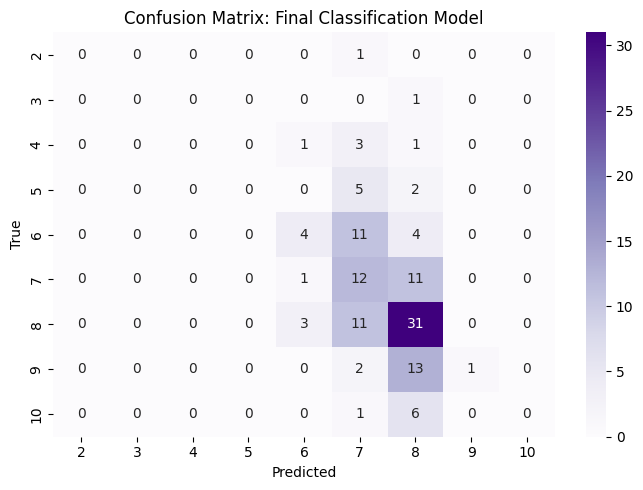

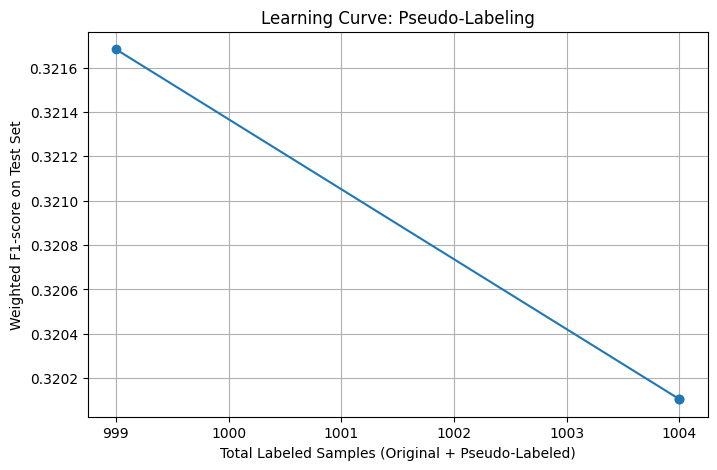

In [183]:
model_pseudo_label_clf = pseudo_label_clf(
    LogisticAT(),
    X_train_w2v, y_train_w2v,
    unlabeled_embeddings_w2v,
    X_test_w2v, y_test_w2v,
    confidence_threshold=0.6,
    max_rounds=5
)

### 6.1.2 Regression

In [164]:
def pseudo_label_reg(
    model,
    X_train_labeled, y_train_labeled,
    X_unlabeled,
    X_test, y_test,
    confidence_threshold,
    max_rounds
):
    for round in range(max_rounds):
        print(f"\nRound {round+1} of Pseudo-Labeling")

        if len(X_unlabeled) == 0:
            print("No more unlabeled data left. Stopping.")
            break

        model.fit(X_train_labeled, y_train_labeled)

        y_unlabeled_pred = model.predict(X_unlabeled)
        y_unlabeled_pred_raw = model.predict(X_unlabeled)
        y_unlabeled_pred = np.clip(np.round(y_unlabeled_pred_raw), 1, 10).astype(int)

        diff_from_int = np.abs(y_unlabeled_pred_raw - np.round(y_unlabeled_pred_raw))
        mask = diff_from_int < confidence_threshold
        n_selected = np.sum(mask)

        if n_selected == 0:
            print("No high-confidence samples found. Stopping early.")
            break

        print(f"Selected {n_selected} pseudo-labeled samples (confidence < {confidence_threshold})")

        pseudo_X = X_unlabeled[mask]
        pseudo_y = np.clip(np.round(y_unlabeled_pred[mask]), 1, 10).astype(int)

        X_train_labeled = np.vstack([X_train_labeled, pseudo_X])
        y_train_labeled = np.concatenate([y_train_labeled, pseudo_y])

        X_unlabeled = X_unlabeled[~mask]

    print("\nFinal Training on Expanded Dataset")
    model.fit(X_train_labeled, y_train_labeled)
    y_pred_test = model.predict(X_test)

    y_pred_clipped = np.clip(np.round(y_pred_test), 1, 10).astype(int)

    print("\nFinal Evaluation (on Test Set)")
    print(classification_report(y_test, y_pred_clipped, digits=3, zero_division=0))
    acc = accuracy_score(y_test, y_pred_clipped)
    print(f"Accuracy (rounded): {acc:.3f}")
    mae = mean_absolute_error(y_test, y_pred_test)
    mse = mean_squared_error(y_test, y_pred_test)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred_test)

    print(f"\nRegression Metrics:")
    print(f"MAE: {mae:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²: {r2:.3f}")

    cm = confusion_matrix(y_test, y_pred_clipped, labels=np.unique(y_test))
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title("Confusion Matrix: Final Model (Test Set)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()
    return model


Round 1 of Pseudo-Labeling
Selected 3994 pseudo-labeled samples (confidence < 0.4)

Round 2 of Pseudo-Labeling
Selected 301 pseudo-labeled samples (confidence < 0.4)

Round 3 of Pseudo-Labeling
Selected 107 pseudo-labeled samples (confidence < 0.4)

Round 4 of Pseudo-Labeling
Selected 46 pseudo-labeled samples (confidence < 0.4)

Round 5 of Pseudo-Labeling
Selected 21 pseudo-labeled samples (confidence < 0.4)

Final Training on Expanded Dataset

Final Evaluation (on Test Set)
              precision    recall  f1-score   support

           2      0.000     0.000     0.000         1
           3      0.000     0.000     0.000         1
           4      0.000     0.000     0.000         5
           5      0.000     0.000     0.000         7
           6      0.333     0.211     0.258        19
           7      0.293     0.708     0.415        24
           8      0.481     0.578     0.525        45
           9      0.000     0.000     0.000        16
          10      0.000     0.0

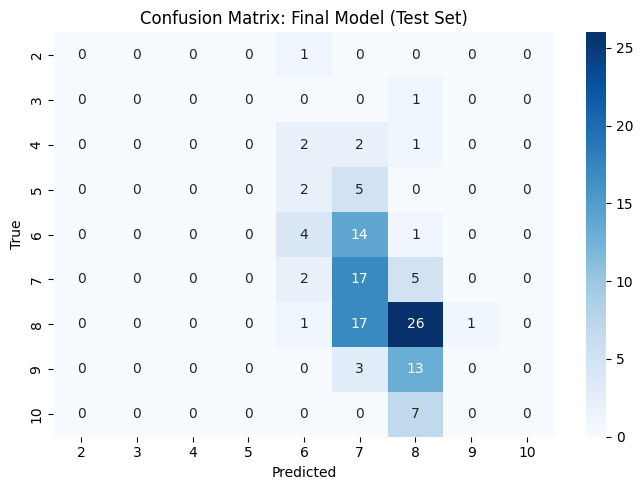

In [147]:
model_pseudo_label_reg = pseudo_label_reg(
    SVR(),
    X_train_st, y_train_st,
    unlabeled_embeddings_st,
    X_test_st, y_test_st,
    confidence_threshold=0.4,
    max_rounds=5
)

## 6.2 Active Learning

In [ ]:
def compute_uncertainty_scores(model, strategy, X_unlabeled):
  proba = model.predict_proba(X_unlabeled)
  if strategy == 'entropy':
    return entropy(proba.T)
  elif strategy == 'least_confident':
    max_proba = np.max(proba, axis=1)
    return 1 - max_proba
  elif strategy == 'margin':
    sorted_proba = np.sort(proba, axis=1)
    margin = sorted_proba[:, -1] - sorted_proba[:, -2]
    return 1 - margin
  else:
    raise ValueError(f"Unknown uncertainty strategy: {strategy}")

In [ ]:
def evaluate_model_al(model, X_test, y_test):
  y_pred = model.predict(X_test)

  metrics = {
      'accuracy': accuracy_score(y_test, y_pred),
      'f1_score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
      'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
      'recall': recall_score(y_test, y_pred, average='weighted', zero_division=0)
  }

  table = [(k, f"{v:.4f}") for k, v in metrics.items()]
  print("\n" + tabulate(table, headers=["Metric", "Score"], tablefmt="fancy_grid") + "\n")

  return metrics

In [185]:
def plot_learning_curves(performance, cumulative_labeled, strategy):
    f1_scores = [p['f1_score'] for p in performance]

    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_labeled, f1_scores, 'b-o', linewidth=3, markersize=8,
             label=f'F1-Score ({strategy})')
    plt.xlabel('Number of Labeled Samples', fontsize=12)
    plt.ylabel('F1-Score', fontsize=12)
    plt.title('Learning Curve: F1-Score vs Number of Labeled Samples', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=12)

    max_f1_idx = np.argmax(f1_scores)
    plt.annotate(f'Max F1: {f1_scores[max_f1_idx]:.3f}',
                xy=(cumulative_labeled[max_f1_idx], f1_scores[max_f1_idx]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    plt.tight_layout()
    plt.show()

    print("\n" + "="*50)
    print("ACTIVE LEARNING PERFORMANCE SUMMARY")
    print("="*50)
    print(f"Strategy: {strategy}")
    print(f"Initial labeled samples: {cumulative_labeled[0]}")
    print(f"Final labeled samples: {cumulative_labeled[-1]}")
    print(f"Initial F1-Score: {f1_scores[0]:.4f}")
    print(f"Final F1-Score: {f1_scores[-1]:.4f}")
    print(f"F1-Score improvement: {f1_scores[-1] - f1_scores[0]:.4f}")
    print(f"Best F1-Score: {max(f1_scores):.4f} (at {cumulative_labeled[np.argmax(f1_scores)]} samples)")
    print("="*50)

In [187]:
def active_learning(
    model,
    strategy,
    X_train, y_train,
    X_unlabeled_df,
    X_test, y_test,
    rounds,
    k):

    performance = []
    cumulative_labeled = [len(y_train)]

    model.fit(X_train, y_train)
    initial_metrics = evaluate_model_al(model=model, X_test=X_test, y_test=y_test)
    performance.append(initial_metrics)
    print(f"Initial Test Accuracy: {initial_metrics['accuracy']:.4f} with {len(y_train)} labeled samples")

    for round_num in range(rounds):
        print(f"\nRound {round_num + 1}/{rounds}")

        embeddings = np.stack(X_unlabeled_df['embeddings'].values)
        uncertainty_scores = compute_uncertainty_scores(model, strategy, embeddings)
        uncertain_indices = np.argsort(uncertainty_scores)[-k:]

        new_X = []
        new_y = []

        for idx in uncertain_indices:
            sample = X_unlabeled_df.iloc[idx]
            review_text = sample['review_text']
            print(f"Review Text:\n{review_text}")

            while True:
                label = input("Please enter an integer label between 1 and 10: ")
                if label.isdigit() and 1 <= int(label) <= 10:
                    break
                print("Invalid input. Enter an integer between 1 and 10.")

            new_X.append(sample['embeddings'])
            new_y.append(int(label))

        X_train = np.vstack([X_train, new_X])
        y_train = np.concatenate([y_train, new_y])

        X_unlabeled_df = X_unlabeled_df.drop(X_unlabeled_df.index[uncertain_indices])
        cumulative_labeled.append(len(y_train))

        model.fit(X_train, y_train)
        metrics = evaluate_model_al(model=model, X_test=X_test, y_test=y_test)
        performance.append(metrics)
        print(f"Test Accuracy: {metrics['accuracy']:.4f} with {len(y_train)} labeled samples")

    print(f"\nFinal Accuracy: {performance[-1]['accuracy']:.4f}")

    plot_learning_curves(performance, cumulative_labeled, strategy)

    return model

In [ ]:
X_unlabeled_df = unlabeled_reviews_df.copy()
X_unlabeled_df['embeddings'] = list(unlabeled_embeddings_w2v)

### 6.2.1 Least Confidence Sampling


╒═══════════╤═════════╕
│ Metric    │   Score │
╞═══════════╪═════════╡
│ accuracy  │  0.384  │
├───────────┼─────────┤
│ f1_score  │  0.3217 │
├───────────┼─────────┤
│ precision │  0.3531 │
├───────────┼─────────┤
│ recall    │  0.384  │
╘═══════════╧═════════╛

Initial Test Accuracy: 0.3840 with 999 labeled samples

Round 1/5
Review Text:
While the last boss is unnecessarily cheap (come on, we all saw that coming) and the graphics are nothing to write home about, I was happy to find that there were plenty of nuances to the fighting, and there was clearly much thought given to its design. Senko no Ronde 2 is an oddball title that’s not for everyone and the story mode is a complete waste, but for those who find themselves in the Venn diagram intersection of fighting games, anime, giant robots, and shmups, there’s nothing else on the market like it.
Please enter an integer label between 1 and 10: 7
Review Text:
In truth Wolverine could have scored higher simply due to more time being 

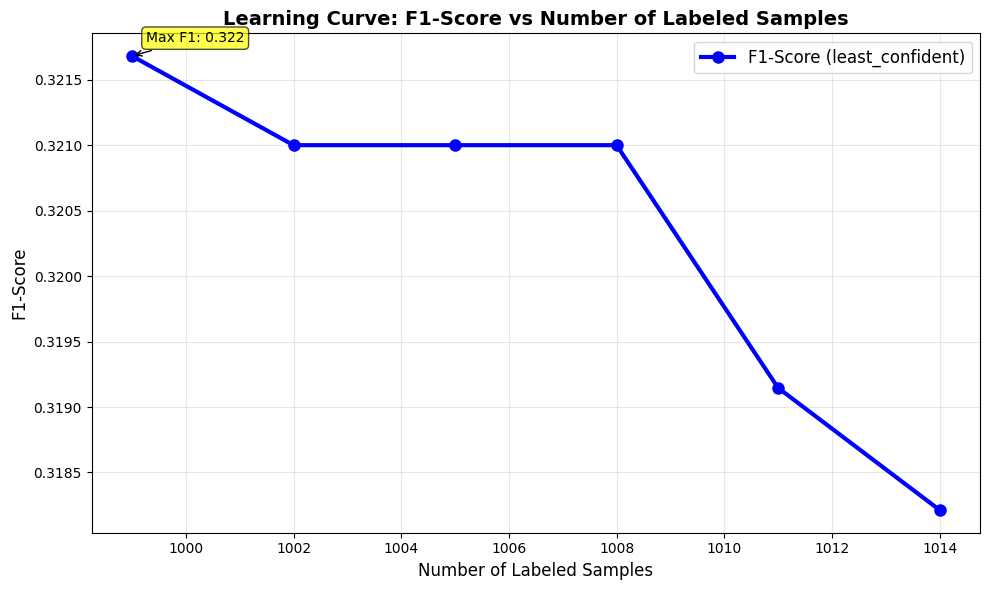


ACTIVE LEARNING PERFORMANCE SUMMARY
Strategy: least_confident
Initial labeled samples: 999
Final labeled samples: 1014
Initial F1-Score: 0.3217
Final F1-Score: 0.3182
F1-Score improvement: -0.0035
Best F1-Score: 0.3217 (at 999 samples)


In [191]:
model_al_least_confidence = active_learning(
    model=LogisticAT(),
    strategy='least_confident',
    X_train=X_train_w2v, y_train=y_train_w2v,
    X_unlabeled_df=X_unlabeled_df,
    X_test=X_test_w2v,
    y_test=y_test_w2v,
    rounds=5,
    k=3)

### 6.2.2 Margin Sampling


╒═══════════╤═════════╕
│ Metric    │   Score │
╞═══════════╪═════════╡
│ accuracy  │  0.384  │
├───────────┼─────────┤
│ f1_score  │  0.3217 │
├───────────┼─────────┤
│ precision │  0.3531 │
├───────────┼─────────┤
│ recall    │  0.384  │
╘═══════════╧═════════╛

Initial Test Accuracy: 0.3840 with 999 labeled samples

Round 1/5
Review Text:
NBA 2K23 is the Michael Jordan of the basketball games. Stunning visuals, improved gameplay and the additions of Eras to the MyNBA mode and the Jordan Challenges make it a must-have for basketball fans. The only issue with NBA 2K23 is an old one: microtransactions. But, if you're a 2K fan, you already know that.
Please enter an integer label between 1 and 10: 9
Review Text:
In truth Wolverine could have scored higher simply due to more time being allowed for bug testing, and possibly having no association with the terrible film. But that doesn’t prevent it from being a good solid, and ultimately, fun game.
Please enter an integer label between 1 a

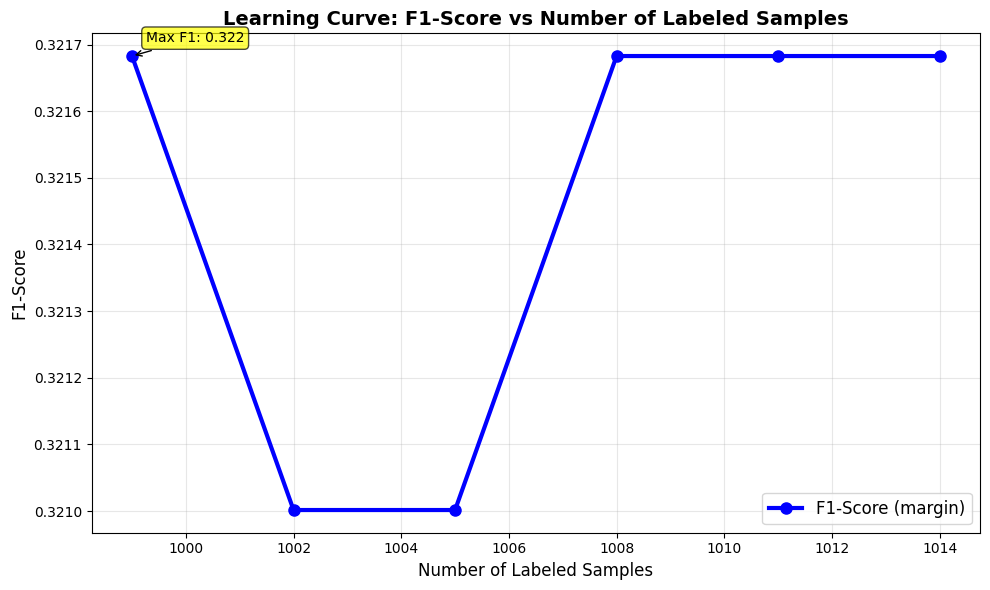


ACTIVE LEARNING PERFORMANCE SUMMARY
Strategy: margin
Initial labeled samples: 999
Final labeled samples: 1014
Initial F1-Score: 0.3217
Final F1-Score: 0.3217
F1-Score improvement: 0.0000
Best F1-Score: 0.3217 (at 999 samples)


In [192]:
model_al_margin = active_learning(
    model=LogisticAT(),
    strategy='margin',
    X_train=X_train_w2v, y_train=y_train_w2v,
    X_unlabeled_df=X_unlabeled_df,
    X_test=X_test_w2v,
    y_test=y_test_w2v,
    rounds=5,
    k=3)

### 6.2.3 Entropy-Based Sampling


╒═══════════╤═════════╕
│ Metric    │   Score │
╞═══════════╪═════════╡
│ accuracy  │  0.384  │
├───────────┼─────────┤
│ f1_score  │  0.3217 │
├───────────┼─────────┤
│ precision │  0.3531 │
├───────────┼─────────┤
│ recall    │  0.384  │
╘═══════════╧═════════╛

Initial Test Accuracy: 0.3840 with 999 labeled samples

Round 1/5
Review Text:
Firefall has its problems. There’s no denying that, but after spending a little time with it, I found myself having a pretty decent time. Sure, it does feel wonky at times, but I couldn’t help but keep playing.
Please enter an integer label between 1 and 10: 6
Review Text:
If Gripshift’s controls were anything resembling playable, the objectives were time-based instead of focused on collecting, and the game had a little bit of personality, Sidhe and Sony Online might have a sleeper hit on their hands.
Please enter an integer label between 1 and 10: 4
Review Text:
As the basis for a full-on action game, Castlevania: Judgment might have worked, but 

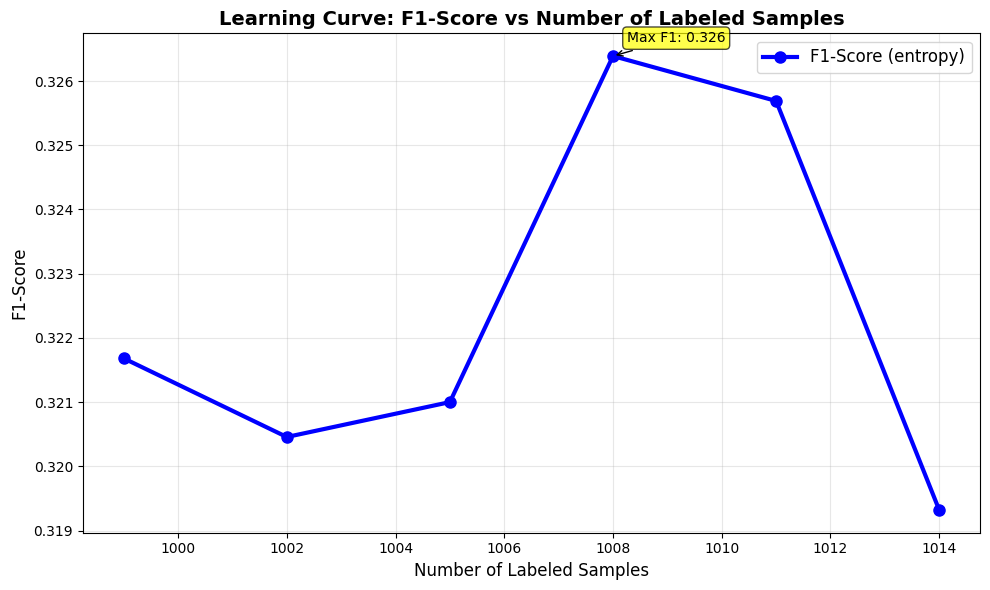


ACTIVE LEARNING PERFORMANCE SUMMARY
Strategy: entropy
Initial labeled samples: 999
Final labeled samples: 1014
Initial F1-Score: 0.3217
Final F1-Score: 0.3193
F1-Score improvement: -0.0024
Best F1-Score: 0.3264 (at 1008 samples)


In [195]:
model_al_entropy = active_learning(
    model=LogisticAT(),
    strategy='entropy',
    X_train=X_train_w2v, y_train=y_train_w2v,
    X_unlabeled_df=X_unlabeled_df,
    X_test=X_test_w2v,
    y_test=y_test_w2v,
    rounds=5,
    k=3)

# **7. Comparative Performance Analysis**

## 7.1 ROC and AUC curves

In [142]:
def plot_roc_auc(model, X_test, y_test):
  y_score = model.predict_proba(X_test)
  classes = np.unique(y_test)
  y_test_bin = label_binarize(y_test, classes=classes)
  n_classes = len(classes)

  fpr = dict()
  tpr = dict()
  roc_auc = dict()
  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

  plt.figure()
  for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

  plt.plot([0, 1], [0, 1], 'k--', lw=2)
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('Multi-class ROC Curve')
  plt.legend(loc="lower right")
  plt.grid()
  plt.show()

Psuedo Labeling using Classification model and Word2Vec labeling

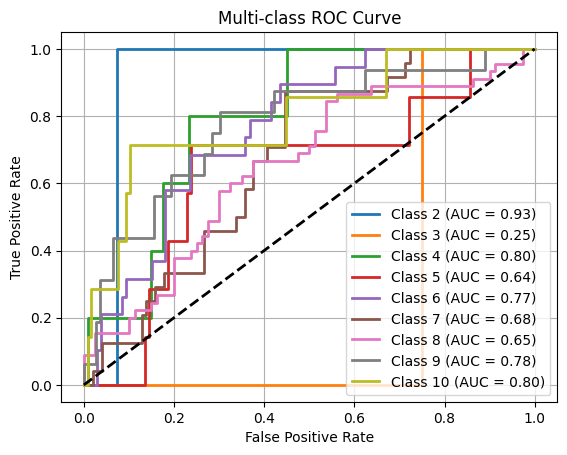

In [143]:
plot_roc_auc(model_pseudo_label_clf, X_test_w2v, y_test_w2v)

Active Learning using Least Confidence Sampling Strategy

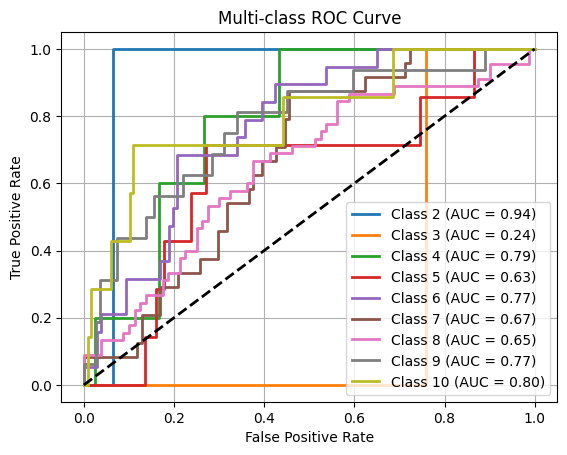

In [193]:
plot_roc_auc(model_al_least_confidence, X_test_w2v, y_test_w2v)

Active Learning using Margin Sampling Strategy

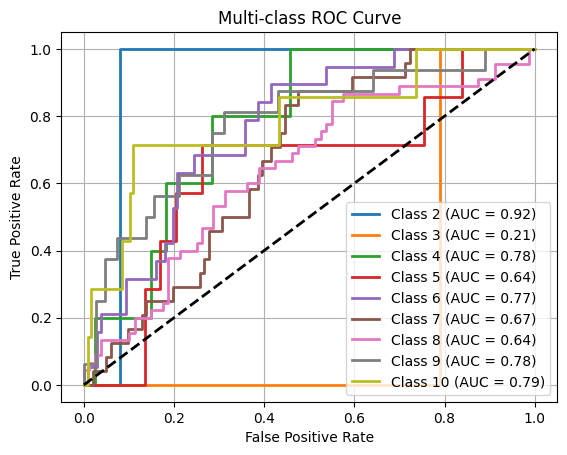

In [194]:
plot_roc_auc(model_al_margin, X_test_w2v, y_test_w2v)

Active Learning using Entropy Sampling Strategy

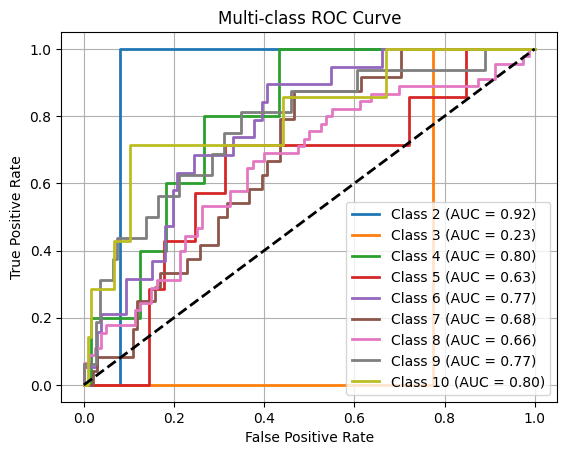

In [196]:
plot_roc_auc(model_al_entropy, X_test_w2v, y_test_w2v)

## 7.2 Discussion

When choosing between SSL approaches with your specific setup (sentence transformers, Word2Vec, regression/classification), several key factors should guide your decision:

**Pseudo-Labeling works best when:**
- You have a relatively clean, well-structured dataset where initial model predictions are likely to be reasonably accurate
- Your labeled data is representative of the overall distribution
- The decision boundary is relatively clear (not in highly ambiguous regions)
- You have sufficient computational resources for iterative retraining

**Active Learning excels when:**
- Your dataset contains many ambiguous or borderline cases where human expertise is crucial
- There's high class imbalance or complex decision boundaries
- You have access to domain experts who can provide high-quality labels
- Budget constraints make every labeled example count

**Model Type Considerations**

**With Sentence Transformers:**
- Active Learning leverages the rich semantic representations well - you can use uncertainty sampling in the embedding space to find truly informative examples
- Pseudo-labeling can propagate semantic understanding effectively, but be cautious of domain shift between your labeled and unlabeled data

**With Word2Vec:**
- The simpler representations may make Active Learning's uncertainty estimates less reliable
- Pseudo-labeling might struggle with out-of-vocabulary words or domain-specific terminology not well-represented in your initial embeddings

**Trade-offs and Pitfalls**

**Pseudo-Labeling Risks:**
- **Confirmation bias**: The model reinforces its initial biases, potentially ignoring minority classes or edge cases
- **Error propagation**: Incorrect pseudo-labels compound over iterations
- **Distribution drift**: May not adapt well to changing data distributions
- **Overconfidence**: Models can become overly confident in wrong predictions

**Active Learning Pitfalls:**
- **Sampling bias**: May focus too heavily on outliers or adversarial examples
- **Oracle inconsistency**: Human annotators may be inconsistent, especially for ambiguous cases
- **Computational overhead**: Requires frequent model retraining and uncertainty calculation
- **Query strategy limitations**: Simple uncertainty sampling may not capture true informativeness